# Training Specific Attributes: Sign Shape

## 0. Hardware Summary

The following hardware was used for training and validation:

- **CPU:** AMD Ryzen 9 5950X - 16 Cores / 32 Threads
- **RAM:** 64 GB
- **GPU:** NVIDIA GeForce RTX 5070 Ti - 16 GB
- **CUDA:** Version 13.1


## 1. Setup

### i. Necessary Imports


In [13]:
# For model
from ultralytics import YOLO, settings
import torch

# For visualization
import matplotlib.pyplot as plt
import pandas as pd

# For data handling
import os
import cv2
import yaml
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # avoid kernel crash during training step
import zipfile
import shutil
import gc


### ii. Monitoring

In [3]:
# Enable TensorBoard logging
settings.update({'tensorboard': True})

print('TensorBoard logging enabled.')
print('run "tensorboard --logdir=runs" to view logs.')


TensorBoard logging enabled.
run "tensorboard --logdir=runs" to view logs.


### iii. Define the models to use

In [4]:
modelnames = {
    'yolo12l_pretrained': os.path.join('runs', 'yolo12l_general_signs', 'weights', 'best'),
    'yolo12l_default': 'yolo12l'
}

### iv. Ensure cuda availability

In [5]:
if torch.cuda.is_available():
    print(f'CUDA is available context device: {torch.cuda.get_device_name(0)}')
else:
    print('CUDA is not available. Training will run on CPU.')

CUDA is not available. Training will run on CPU.


### v. Display dataset folder structure

In [6]:
# /F=show files, /A=use ASCII characters
output = !tree Dataset /F /A

# Print the output skipping the first 3 lines (Header/Path info)
print('Dataset/\n'+'\n'.join(output[3:]))

Dataset/
|   merged_images.zip
|   merged_input.json
|   
+---COCO-Format Annotations
|       COCO.json
|       COCO_condition.json
|       COCO_mounting.json
|       COCO_sign_shape.json
|       COCO_view_angle.json
|       
+---Individuals
|       images_Amy_Spiteri.zip
|       images_Daniel_Pace.zip
|       images_Ellyn_Rose_Debrincat.zip
|       images_Joachim_Grech.zip
|       input_Amy_Spiteri.json
|       input_Daniel_Pace.json
|       input_Ellyn_Rose_Debrincat.json
|       input_Joachim_Grech.json
|       
\---Train-Test-Val Split
    |   images.zip
    |   
    +---COCO-based
    |   +---COCO-based_COCO
    |   |   \---annotations
    |   |           test.json
    |   |           train.json
    |   |           val.json
    |   |           
    |   +---COCO-based_COCO_condition
    |   |   \---annotations
    |   |           test.json
    |   |           train.json
    |   |           val.json
    |   |           
    |   +---COCO-based_COCO_mounting
    |   |   \---annotation

### vi. Paths

In [7]:
DATASET_ROOT = os.path.join('Dataset', 'Train-Test-Val Split')
YOLO_YAML_PATH = os.path.join(DATASET_ROOT, 'YOLO', 'YOLO_COCO_sign_shape', 'data.yaml')

# For unzipping images if needed
ZIP_PATH = os.path.join(DATASET_ROOT, 'images.zip')
ZIP_EXTRACT_PATH = os.path.join(DATASET_ROOT, 'YOLO', 'YOLO_COCO_sign_shape') # Change for different models/learning tasks

# Correct the yaml paths for current user:
# Load the current yaml
with open(YOLO_YAML_PATH, 'r') as f:
    data = yaml.safe_load(f)

# Update the paths
data['path'] = os.path.abspath(ZIP_EXTRACT_PATH)
data['train'] = os.path.join(data['path'], 'images', 'train')
data['val'] = os.path.join(data['path'], 'images', 'val')
data['test'] = os.path.join(data['path'], 'images', 'test')

# Save the updated yaml
with open(YOLO_YAML_PATH, 'w') as f:
    yaml.safe_dump(data, f, width=float('inf'))
    
print(f'Updated YAML paths in {YOLO_YAML_PATH}')

Updated YAML paths in Dataset\Train-Test-Val Split\YOLO\YOLO_COCO_sign_shape\data.yaml


### vii. Extract `images.zip` if necessary

In [8]:
# ensure destination is correct
if os.path.exists(ZIP_EXTRACT_PATH):
    
    # Check if the contents are already extracted
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_contents = zip_ref.namelist()
        
        # If there are contents in the zip file
        if zip_contents:
            item_path = os.path.join(ZIP_EXTRACT_PATH, zip_contents[0])
            
            # If the first item in the zip already exists in the extract path, skip extraction
            if os.path.exists(item_path):
                print(f'Contents already extracted to {ZIP_EXTRACT_PATH}. Skipping extraction.')
            
            # Else extract the contents
            else:
                print(f'Extracting {ZIP_PATH} to {ZIP_EXTRACT_PATH}...')
                zip_ref.extractall(ZIP_EXTRACT_PATH)
                print('Extraction complete.')
        else:
            print(f'Zip file {ZIP_PATH} is empty. No extraction performed.')

Extracting Dataset\Train-Test-Val Split\images.zip to Dataset\Train-Test-Val Split\YOLO\YOLO_COCO_sign_shape...
Extraction complete.


## 2. Training

In [8]:
for modelname, weight_path in modelnames.items():
    
    # load model
    model = YOLO(f'{weight_path}.pt')
    
    if model.task == 'train':
        model.task = 'detect' # i dont get why this is necessary

    model.train(
        data=YOLO_YAML_PATH,
        epochs=100,                                         # default
        batch=12,                                           # autobatch 60% gpu usage
        patience=20,                                        # early stopping after 20 epochs of no improvement
        device=0 if torch.cuda.is_available() else 'cpu',   # use GPU if available
        imgsz=640,                                          # default
        project='runs',
        task='detect',
        name=f'{modelname}_sign_shape',                     # folder name for results
        save_period=10,                                     # save every 10 epochs
        exist_ok=True                                       # overwrite existing results
    )
    
    # clean up memory
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        
    # del cache files
    

New https://pypi.org/project/ultralytics/8.4.5 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.2  Python-3.10.19 torch-2.9.1+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Dataset\Train-Test-Val Split\YOLO\YOLO_COCO_sign_shape\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs\yolo12l_general_signs\weights\best.pt, 

c:\Users\Daniel\miniconda3\envs\ARI3129\lib\site-packages\torch\jit\_trace.py:685: UserWarning: The input to trace is already a ScriptModule, tracing it is a no-op. Returning the object as is.
  warnings.warn(


Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to C:\Users\Daniel\OneDrive\Desktop\Programs\Python\ari3129-cv-group-project\runs\yolo12l_pretrained_sign_shape
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100      12.3G     0.4152      2.919     0.8734         16        640: 100% ━━━━━━━━━━━━ 41/41 1.4it/s 30.3s0.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.9it/s 2.6s0.3ss
                   all        111        174      0.741      0.342      0.393       0.33

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100      12.5G     0.3977      1.238     0.8577         11        640: 100% ━━━━━━━━━━━━ 41/41 2.2it/s 19.0s0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 5.1it/s 1.0s0.3s
                   all       

c:\Users\Daniel\miniconda3\envs\ARI3129\lib\site-packages\torch\jit\_trace.py:685: UserWarning: The input to trace is already a ScriptModule, tracing it is a no-op. Returning the object as is.
  warnings.warn(


Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to C:\Users\Daniel\OneDrive\Desktop\Programs\Python\ari3129-cv-group-project\runs\yolo12l_default_sign_shape
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100      12.4G     0.7991      3.647      1.115         16        640: 100% ━━━━━━━━━━━━ 41/41 1.6it/s 26.3s0.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 4.9it/s 1.0s0.3s
                   all        111        174      0.659      0.221      0.237      0.201

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100      12.5G     0.6953      1.937      1.061         11        640: 100% ━━━━━━━━━━━━ 41/41 1.8it/s 22.3s0.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 4.4it/s 1.1s0.3s
                   all        11

## 3. Testing & Evaluation

### i. Paths

In [9]:
TEST_PATH = os.path.join(DATASET_ROOT,'YOLO', 'YOLO_COCO_sign_shape', 'images', 'test')

### ii. Select model

In [10]:
modelfilenames = [f'{modelname}_sign_shape' for modelname in modelnames.keys()]

### iii. Compare Results

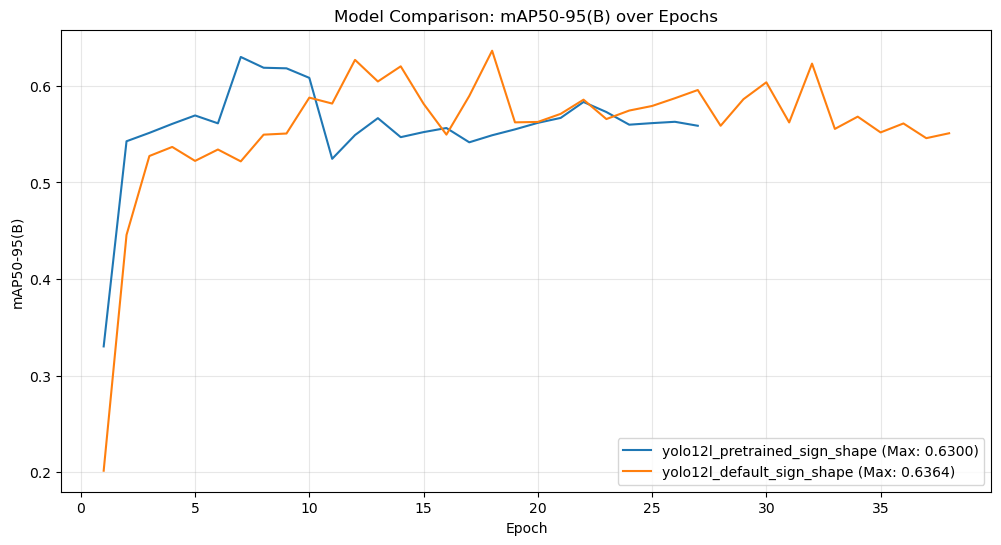


Best Model Performance Summary:
                        Model  Best mAP50-95  Best mAP50  Epoch
   yolo12l_default_sign_shape        0.63644     0.75617     18
yolo12l_pretrained_sign_shape        0.62998     0.74743      7


In [11]:
plt.figure(figsize=(12, 6))

best_results = []

for modelfilename in modelfilenames:
    results_path = os.path.join('runs', modelfilename, 'results.csv')

    if os.path.exists(results_path):
        # Read the results file
        try:
            df = pd.read_csv(results_path)
            
            # Clean column names (remove extra spaces)
            df.columns = df.columns.str.strip()
            
            # Get the mAP50-95 metric
            map_col = 'metrics/mAP50-95(B)'
            
            if map_col in df.columns:
                # Plot
                plt.plot(df['epoch'], df[map_col], label=f'{modelfilename} (Max: {df[map_col].max():.4f})')
                
                # Store best result
                best_results.append({
                    'Model': modelfilename,
                    'Best mAP50-95': df[map_col].max(),
                    'Best mAP50': df['metrics/mAP50(B)'].max() if 'metrics/mAP50(B)' in df.columns else None,
                    'Epoch': df.loc[df[map_col].idxmax(), 'epoch']
                })
        except Exception as e:
            print(f"Error reading {results_path}: {e}")
                
    else:
        print(f"Warning: No results found for {modelfilename} at {results_path}")

plt.title('Model Comparison: mAP50-95(B) over Epochs')
plt.xlabel('Epoch')
plt.ylabel('mAP50-95(B)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Display summary table
if best_results:
    results_df = pd.DataFrame(best_results)
    results_df = results_df.sort_values(by='Best mAP50-95', ascending=False).reset_index(drop=True)
    print("\nBest Model Performance Summary:")
    print(results_df.to_string(index=False))

## 4. Analytics for Single Input Image
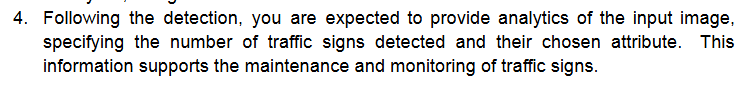


image 1/1 c:\Users\Daniel\OneDrive\Desktop\Programs\Python\ari3129-cv-group-project\Dataset\Train-Test-Val Split\YOLO\YOLO_COCO_sign_shape\images\test\00e70ac4-IMG_20251111_140913.jpg: 640x480 2 Circulars, 212.9ms
Speed: 2.1ms preprocess, 212.9ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 480)
Number of traffic signs detected: 2
Detected Attributes (Sign Type):
- Circular (0.86)
- Circular (0.31)


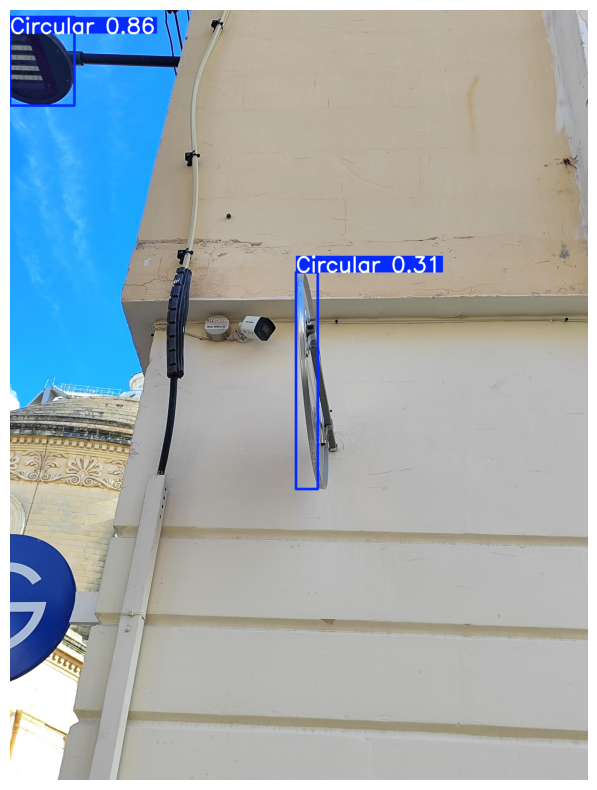

In [ ]:
# 1. Specify image path:
TEST_IMGS = os.listdir(TEST_PATH)

img = os.path.join(TEST_PATH, TEST_IMGS[1])

# 2. Load the Model
model_path = os.path.join('TensorBoard', 'runs', 'sign-shape', 'weights', 'best.pt')
model = YOLO(model_path, task='detect')

# set model to predict mode 
if model.task != 'detect':
    model.task = 'detect'

# 3. Run Inference
results = model(img) # removed conf=0.5
result = results[0]  # Get the first (and only) result

# 4. Output Text Results
print(f"Number of traffic signs detected: {len(result.boxes)}")
print("Detected Attributes (Sign Type):")

for box in result.boxes:
    cls_id = int(box.cls[0])
    label_name = result.names[cls_id]
    score = float(box.conf[0])
    print(f"- {label_name} ({score:.2f})")

# 5. Display Image with Bounding Boxes
# result.plot() returns the image with boxes drawn in BGR format
img_plotted = result.plot()
img_rgb = cv2.cvtColor(img_plotted, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 10))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

## 5. clean up files 🧹🧹🍃

<span style='color:red'>Double check paths are correct, so u dont delete the wrong <s>shi</s> files</span>

In [ ]:
# remove the images folder to save space
images_path = os.path.join(ZIP_EXTRACT_PATH, 'images')
if os.path.exists(images_path):
    shutil.rmtree(images_path)
    print(f"Removed images folder at {images_path} to save space.")
    
# remove the unnecessary yolo11 file that gets downloaded during training for reasons unknown
if os.path.exists('yolo11n.pt'):
    os.remove('yolo11n.pt')
    print("Removed unnecessary yolo11n.pt file.")

cache_paths = [YOLO_YAML_PATH.replace('data.yaml', os.path.join('labels', 'train.cache')), YOLO_YAML_PATH.replace('data.yaml', os.path.join('labels', 'val.cache'))]
for cache_path in cache_paths:
    if os.path.exists(cache_path):
        os.remove(cache_path)
        print(f"Removed cache file at {cache_path}.")

Removed images folder at Dataset\Train-Test-Val Split\YOLO\YOLO_COCO_sign_shape\images to save space.
Removed unnecessary yolo11n.pt file.
Removed cache file at Dataset\Train-Test-Val Split\YOLO\YOLO_COCO_sign_shape\labels\train.cache.
Removed cache file at Dataset\Train-Test-Val Split\YOLO\YOLO_COCO_sign_shape\labels\val.cache.
